# Analisis Kualitas Polutan SO2 Kec. Labang, Kab. Bangkalan


## 0. Ringkasan

1. **Cakupan wilayah** — bukan lagi seluruh Kabupaten Bangkalan (seperti tugas sebelumnya), tetapi **satu kecamatan sesuai kecamatan masing-masing mahasiswa**. Untuk kasus saya: **Kecamatan Labang**
2. **Rentang waktu** — data diambil dari **31 Agustus 2025 sampai 31 Agustus 2026**.
3. **Alur wajib** — data mentah → **deteksi outlier** → **imputasi missing value** → jika data sudah bersih (tidak ada outlier & missing) → **ekstraksi fitur TSFEL sebanyak 68 fitur**

## 1. Business Understanding

### 1.1 Latar belakang

Sulfur dioksida (SO2) adalah salah satu polutan udara utama yang dipantau oleh satelit **Sentinel-5P** milik program Copernicus (Badan Antariksa Eropa). SO2 umumnya berasal dari pembakaran bahan bakar fosil (kendaraan bermotor, industri, pembangkit listrik) dan berkontribusi pada pembentukan ozon troposferik serta hujan asam. Memantau pola SO2 harian di suatu wilayah membantu memahami dinamika pencemaran udara dari waktu ke waktu.

Kecamatan Labang dipilih dengan batas administratif yang direpresentasikan melalui file `Kecamatan_Labang.geojson`.

### 1.2 Tujuan proyek

1. Mengambil data konsentrasi SO2 harian di Kecamatan Labang selama periode 31 Agustus 2025 – 31 Agustus 2026 dari Sentinel-5P (openEO/Copernicus Data Space).
2. Membersihkan data (deteksi outlier + imputasi missing value) sehingga sinyal time series valid untuk diproses lebih lanjut.
3. Meringkas pola time series tersebut menjadi **68 fitur numerik** menggunakan pustaka **TSFEL** (Time Series Feature Extraction Library)
### 1.3 Pertanyaan analisis

> Bagaimana karakteristik statistik, energi, bentuk distribusi, dan pola frekuensi dari time series SO2 Kecamatan Labang selama satu tahun penuh, jika diringkas menggunakan 68 fitur TSFEL?

### 1.4 Kriteria keberhasilan (Definition of Done)

| No | Kriteria | Target |
|---|---|---|
| 1 | Cakupan wilayah | sesuai polygon `Kecamatan_Labang.geojson` |
| 2 | Cakupan waktu | 31-08-2025 s.d. 31-08-2026 |
| 3 | Missing value setelah imputasi | 0 |
| 4 | Outlier setelah penanganan | ditandai & diimputasi, tidak ada nilai ekstrem tersisa |
| 5 | Jumlah fitur output | tepat 68 |
| 6 | File CSV final | tidak dimodifikasi setelah dihasilkan |


## 2. Data Understanding

### 2.1 Sumber data

Data bersumber dari **Sentinel-5P TROPOMI Level-2**, diakses melalui **openEO Copernicus Data Space Ecosystem** (`openeo.dataspace.copernicus.eu`). Koleksi yang dipanggil adalah `SENTINEL_5P_L2` dengan band `SO2`. Satuan konsentrasi kolom SO2 dari produk ini pada umumnya berupa **mol/m²** (densitas kolom troposferik/total), bukan konsentrasi permukaan µg/m³ — ini penting untuk interpretasi, meskipun tidak mengubah prosedur pengolahan statistiknya.

### 2.2 Wilayah kajian (AOI) — GeoJSON Kecamatan Labang

File `Kecamatan_Labang.geojson` berisi **2 feature**:

1. **Titik pusat** (`Point`) Kecamatan Labang pada koordinat **(112.80314, -7.157302)**.
2. **Polygon** batas administratif dengan 5 titik koordinat (titik pertama = titik terakhir, menutup polygon):

| Titik | Longitude | Latitude |
|---|---|---|
| 1 | 112.764412 | -7.164744 |
| 2 | 112.822778 | -7.164744 |
| 3 | 112.822778 | -7.110860 |
| 4 | 112.764412 | -7.110860 |
| 5 (=1) | 112.764412 | -7.164744 |

### 2.3 Variabel time series

| Kolom | Tipe | Keterangan |
|---|---|---|
| `date` | datetime (harian) | tanggal observasi agregat |
| `SO2` | float | rata-rata spasial SO2 di dalam polygon Labang pada tanggal tsb. |

### 2.4 Periode data & ekspektasi jumlah observasi

Rentang **31 Agustus 2025 → 31 Agustus 2026** bersifat **inklusif** pada kedua ujungnya. Karena tahun 2026 bukan tahun kabisat (2026 tidak habis dibagi 4), maka jumlah hari dapat dihitung manual:

- Dari 31-08-2025 sampai 31-08-2026 = tepat 1 tahun kalender.
- 1 tahun (2026 bukan kabisat karena Februari 2026 = 28 hari) + 1 hari (karena kedua ujung inklusif) = **366 hari**.

### 2.5 Potensi masalah kualitas data

Data satelit seperti Sentinel-5P rawan terhadap:

- **Missing value** — akibat tutupan awan tebal, kegagalan retrieval algoritma, atau tidak ada lintasan satelit pada hari tertentu di atas AOI.
- **Outlier** — nilai ekstrem akibat gangguan atmosfer, aerosol, atau kesalahan kalibrasi sesaat.


## 3. Data Preparation

Tahap ini mencakup: instalasi pustaka → pembacaan GeoJSON → pengambilan data Sentinel-5P → konversi ke CSV mentah → pemeriksaan kualitas awal → deteksi outlier (IQR) → pembuatan kalender harian penuh → imputasi missing/outlier → validasi akhir.

### 3.1 Instalasi pustaka


In [1]:
!pip -q install openeo netCDF4 tsfel psycopg2-binary

import os
import json
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.6g}")
print("Semua library utama berhasil di-import.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.0/357.0 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.4/63.4 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.0 MB/s eta 0:00:00
Semua library utama berhasil di-import.


### 3.2 Upload file GeoJSON Kecamatan Labang
pilih file `Kecamatan_Labang.geojson`

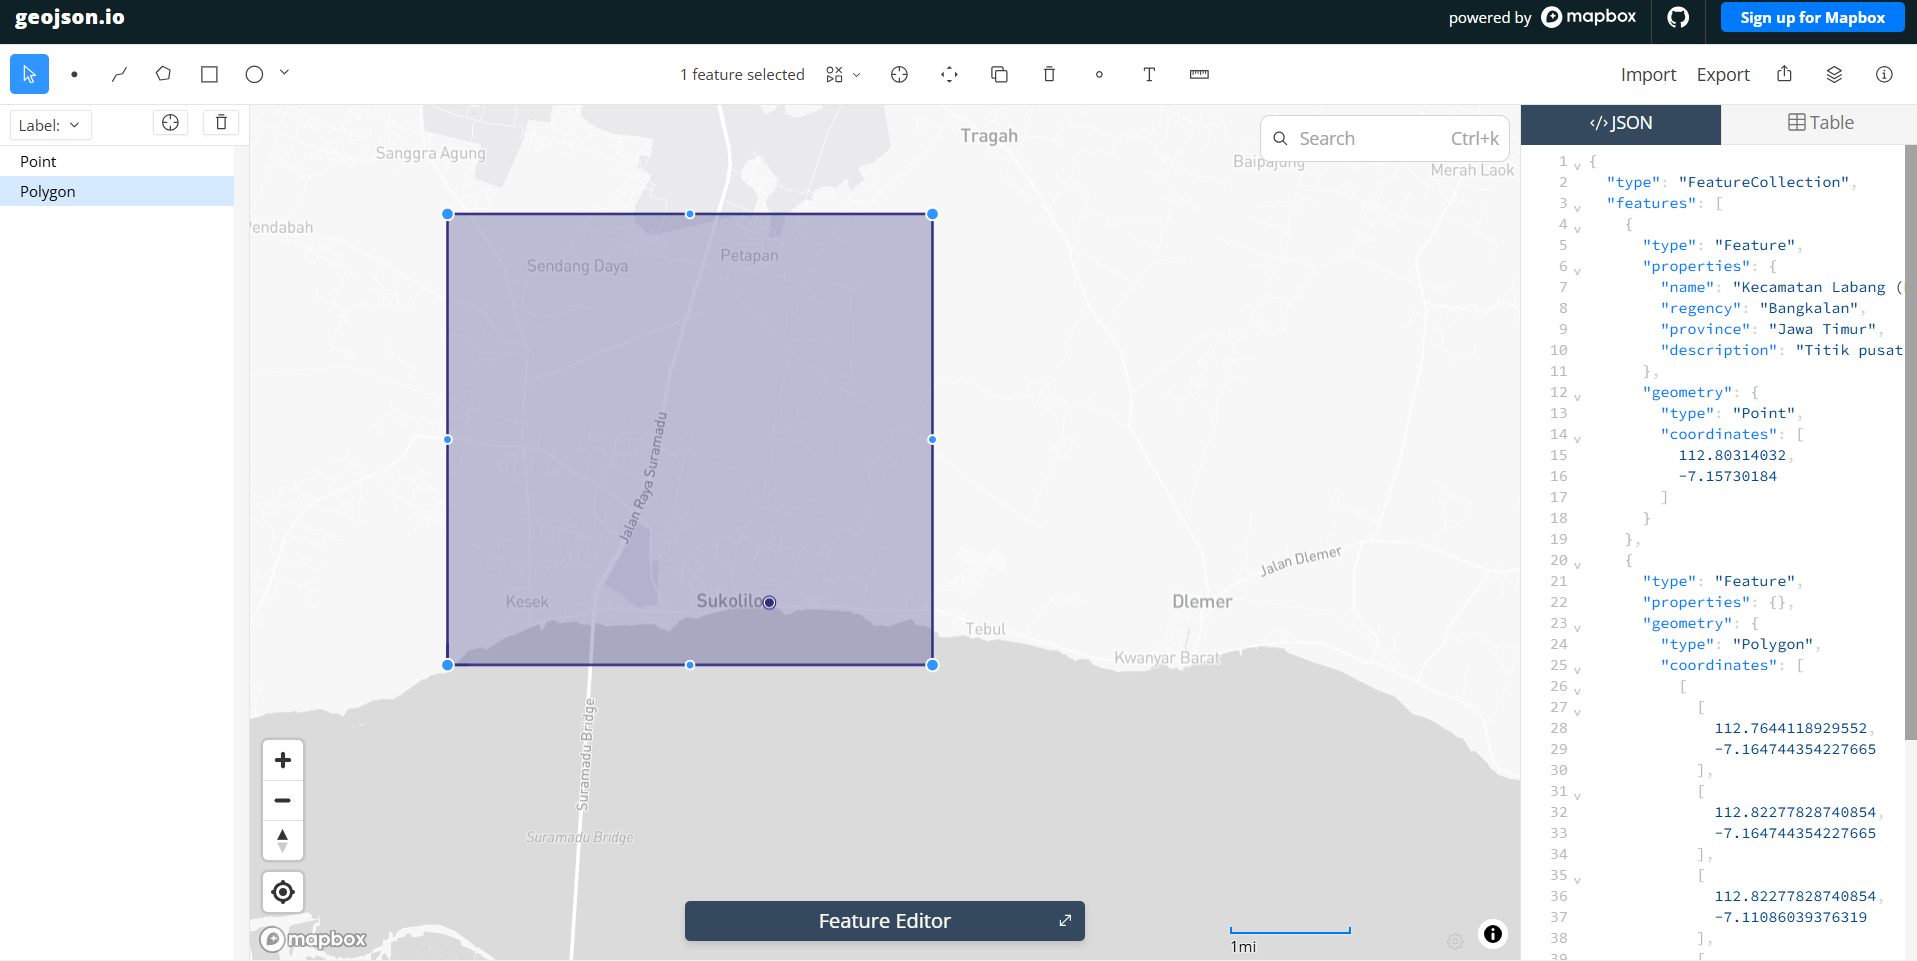

In [2]:
from google.colab import files

uploaded = files.upload()

geojson_candidates = [f for f in uploaded.keys() if f.lower().endswith(".geojson")]
if not geojson_candidates:
    raise FileNotFoundError("Belum ada file GeoJSON yang diunggah. Ulangi upload file Kecamatan_Labang.geojson.")

GEOJSON_PATH = geojson_candidates[0]
print("File GeoJSON yang digunakan:", GEOJSON_PATH)

Saving Kecamatan Labang.geojson to Kecamatan Labang.geojson
File GeoJSON yang digunakan: Kecamatan Labang.geojson


### 3.3 Membaca isi GeoJSON


In [3]:
with open(GEOJSON_PATH, "r", encoding="utf-8") as f:
    labang_geojson = json.load(f)

print("Tipe FeatureCollection :", labang_geojson.get("type"))
print("Jumlah feature         :", len(labang_geojson.get("features", [])))
print()

for i, feature in enumerate(labang_geojson.get("features", [])):
    geom = feature.get("geometry", {})
    print(f"Feature {i}: tipe geometri = {geom.get('type')}, properti = {feature.get('properties', {})}")

Tipe FeatureCollection : FeatureCollection
Jumlah feature         : 2

Feature 0: tipe geometri = Point, properti = {'name': 'Kecamatan Labang (Pusat)', 'regency': 'Bangkalan', 'province': 'Jawa Timur', 'description': 'Titik pusat koordinat Kecamatan Labang'}
Feature 1: tipe geometri = Polygon, properti = {}


### 3.4 Mengambil polygon & menghitung bounding box (AOI)

Bounding box (kotak pembatas) dibutuhkan oleh openEO sebagai parameter `spatial_extent` (`west`, `south`, `east`, `north`). Untuk poligon dengan titik-titik $(x_1, y_1), (x_2, y_2), \dots, (x_n, y_n)$, *bounding box* dihitung dengan:

$$\text{west} = \min(x_1, x_2, \dots, x_n), \qquad \text{east} = \max(x_1, x_2, \dots, x_n)$$
$$\text{south} = \min(y_1, y_2, \dots, y_n), \qquad \text{north} = \max(y_1, y_2, \dots, y_n)$$

di mana $x_i$ adalah bujur (longitude) dan $y_i$ adalah lintang (latitude) titik ke-$i$ pada poligon.

In [4]:
polygon_features = [
    feature for feature in labang_geojson.get("features", [])
    if feature.get("geometry", {}).get("type") == "Polygon"
]

if not polygon_features:
    raise ValueError("GeoJSON tidak memiliki geometry bertipe Polygon.")

aoi = polygon_features[0]["geometry"]
ring = aoi["coordinates"][0]

longitudes = [p[0] for p in ring]
latitudes = [p[1] for p in ring]

west = min(longitudes)
east = max(longitudes)
south = min(latitudes)
north = max(latitudes)

print("Titik-titik polygon (longitude, latitude):")
for i, p in enumerate(ring):
    print(f"  Titik {i+1}: ({p[0]}, {p[1]})")

print()
print("Bounding box AOI Kecamatan Labang:")
print("west  (min longitude) =", west)
print("east  (max longitude) =", east)
print("south (min latitude)  =", south)
print("north (max latitude)  =", north)

Titik-titik polygon (longitude, latitude):
  Titik 1: (112.764412, -7.164744)
  Titik 2: (112.822778, -7.164744)
  Titik 3: (112.822778, -7.11086)
  Titik 4: (112.764412, -7.11086)
  Titik 5: (112.764412, -7.164744)

Bounding box AOI Kecamatan Labang:
west  (min longitude) = 112.764412
east  (max longitude) = 112.822778
south (min latitude)  = -7.164744
north (max latitude)  = -7.11086



### 3.5 Pengambilan data Sentinel-5P SO2 via openEO

Langkah-langkah pada openEO:

1. `openeo.connect(...).authenticate_oidc()` — autentikasi ke Copernicus Data Space.
2. `load_collection("SENTINEL_5P_L2", ...)` — memuat koleksi TROPOMI dengan filter waktu & ruang serta memilih band `SO2`.
3. `aggregate_temporal_period(reducer="mean", period="day")` — meringkas beberapa observasi dalam satu hari menjadi **satu nilai rata-rata harian**.
4. `aggregate_spatial(reducer="mean", geometries=aoi)` — meringkas seluruh piksel di dalam polygon Labang menjadi **satu nilai rata-rata spasial** per hari.
5. `execute_batch(...)` — menjalankan proses di server openEO dan mengunduh hasilnya sebagai file NetCDF (`.nc`).


In [5]:
import openeo

connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()
print("Berhasil terhubung & terautentikasi ke openEO Copernicus Data Space.")

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=BAKZ-RLOK 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.
Berhasil terhubung & terautentikasi ke openEO Copernicus Data Space.


In [6]:
s5SO2 = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-08-31"],
    spatial_extent={
        "west": west,
        "south": south,
        "east": east,
        "north": north
    },
    bands=["SO2"]
)

# Agregasi temporal
s5p_SO2_daily = s5SO2.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

# Agregasi spasial
s5p_SO2_aoi = s5p_SO2_daily.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)

print("Process graph SO2 Kecamatan Labang berhasil disusun.")

Process graph SO2 Kecamatan Labang berhasil disusun.


In [7]:
job_SO2 = s5p_SO2_aoi.execute_batch(
    title="SO2 Kecamatan Labang 2025-08-31 sampai 2026-08-31",
    outputfile="SO2_Labang.nc"
)

print("Batch job dikirim ke server openEO:")
print(job_SO2)

0:00:00 Job 'j-260920093301492facd83ea612e09fbf': send 'start'
0:00:03 Job 'j-260920093301492facd83ea612e09fbf': queued (progress 0%)
0:00:08 Job 'j-260920093301492facd83ea612e09fbf': queued (progress 0%)
0:00:15 Job 'j-260920093301492facd83ea612e09fbf': queued (progress 0%)
0:00:23 Job 'j-260920093301492facd83ea612e09fbf': queued (progress 0%)
0:00:33 Job 'j-260920093301492facd83ea612e09fbf': queued (progress 0%)
0:00:45 Job 'j-260920093301492facd83ea612e09fbf': queued (progress 0%)
0:01:01 Job 'j-260920093301492facd83ea612e09fbf': queued (progress 0%)
0:01:20 Job 'j-260920093301492facd83ea612e09fbf': running (progress N/A)
0:01:44 Job 'j-260920093301492facd83ea612e09fbf': running (progress N/A)
0:02:14 Job 'j-260920093301492facd83ea612e09fbf': running (progress N/A)
0:02:52 Job 'j-260920093301492facd83ea612e09fbf': running (progress N/A)
0:03:39 Job 'j-260920093301492facd83ea612e09fbf': finished (progress 100%)
Batch job dikirim ke server openEO:
<BatchJob job_id='j-260920093301492fa

### 3.6 Konversi NetCDF menjadi time series CSV (data mentah / *raw*)

File NetCDF (`.nc`) adalah format data multidimensi (waktu × nilai). Kita ekstrak dua variabel:

- `t` — waktu (dalam satuan numerik + `units`, misalnya *"days since 2025-08-31"*), dikonversi ke tanggal kalender menggunakan `netCDF4.num2date()`.
- `SO2` — nilai konsentrasi SO2 hasil agregasi harian & spasial.

Hasil disusun menjadi tabel `date, SO2` dan disimpan sebagai `SO2_Labang_raw.csv` — **file ini adalah data mentah, sebelum ada pembersihan apa pun**.

In [8]:
import netCDF4

dsSO2 = netCDF4.Dataset("SO2_Labang.nc")

print("Variabel yang tersedia dalam file NetCDF:")
print(list(dsSO2.variables.keys()))

Variabel yang tersedia dalam file NetCDF:
['t', 'SO2', 'lat', 'lon', 'feature_names']


In [10]:
so2 = dsSO2.variables["SO2"][:].squeeze()
timeSO2 = dsSO2.variables["t"][:]

try:
    time_units = dsSO2.variables["t"].units
    dates = netCDF4.num2date(timeSO2, units=time_units)
except Exception:
    dates = timeSO2

new_dates = [dates[i].strftime("%Y-%m-%d") for i in range(len(dates))]

dfSO2 = pd.DataFrame({
    "date": new_dates,
    "SO2": so2
})

dfSO2["date"] = pd.to_datetime(dfSO2["date"])
dfSO2 = dfSO2.sort_values("date").reset_index(drop=True)

dfSO2.to_csv("SO2_Labang_raw.csv", index=False)

print("File data mentah tersimpan: SO2_Labang_raw.csv")
print("Jumlah baris (observasi mentah):", len(dfSO2))
display(dfSO2.head())
display(dfSO2.tail())

File data mentah tersimpan: SO2_Labang_raw.csv
Jumlah baris (observasi mentah): 235


,date,SO2
0,2025-08-31,0.000429146
1,2025-09-01,0.000298081
2,2025-09-02,0.00010721
3,2025-09-03,-0.000200289
4,2025-09-04,0.000194948


,date,SO2
230,2026-08-26,0.0004233
231,2026-08-27,4.19735e-05
232,2026-08-28,0.000123436
233,2026-08-29,-1.14756e-05
234,2026-08-30,-9.74001e-05


### 3.7 Mengunduh data mentah (belum dibersihkan)

data mentah `SO2_Labang_raw.csv` **diunduh terlebih dahulu** sebagai bukti/arsip sebelum proses cleaning dilakukan. Ini penting untuk transparansi: siapa pun dapat membandingkan data sebelum dan sesudah pembersihan.


In [11]:
from google.colab import files as colab_files

colab_files.download("SO2_Labang_raw.csv")
print("Unduhan dimulai: SO2_Labang_raw.csv (data mentah, sebelum dibersihkan).")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Unduhan dimulai: SO2_Labang_raw.csv (data mentah, sebelum dibersihkan).


### 3.8 Pemeriksaan kualitas data awal

Yang diperiksa pada tahap ini:

- struktur & tipe data;
- jumlah observasi & rentang tanggal;
- duplikasi tanggal;
- jumlah *missing value* (`NaN`);
- nilai tak-hingga (`+inf` / `-inf`);
- statistik deskriptif dasar.

**Rumus statistik dasar**

$$
\text{Mean } (\bar{x}) = \frac{1}{n}\sum_{i=1}^{n} x_i
$$

$$
\text{Median} =
\begin{cases}
x_{(n+1)/2} & \text{jika } n \text{ ganjil} \\[4pt]
\dfrac{x_{n/2} + x_{n/2+1}}{2} & \text{jika } n \text{ genap}
\end{cases}
\quad \text{(urut data naik terlebih dahulu)}
$$

$$
\text{Variance sampel } (s^2) = \frac{1}{n-1}\sum_{i=1}^{n} (x_i - \bar{x})^2
\qquad
\text{Standar deviasi } (s) = \sqrt{s^2}
$$


In [12]:
print("STRUKTUR DATA")
dfSO2.info()

print("\nJUMLAH BARIS")
print(len(dfSO2))

print("\nRENTANG TANGGAL")
print(dfSO2["date"].min(), "sampai", dfSO2["date"].max())

print("\nDUPLIKASI TANGGAL")
print(dfSO2["date"].duplicated().sum())

dfSO2["SO2"] = pd.to_numeric(dfSO2["SO2"], errors="coerce")

print("\nJUMLAH MISSING VALUE")
print(dfSO2["SO2"].isna().sum())

print("\nNILAI TAK-HINGGA")
print("Positive infinity:", np.isposinf(dfSO2["SO2"]).sum())
print("Negative infinity:", np.isneginf(dfSO2["SO2"]).sum())

print("\nSTATISTIK DESKRIPTIF (pandas)")
print(dfSO2["SO2"].describe())

STRUKTUR DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    235 non-null    datetime64[ns]
 1   SO2     235 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.8 KB

JUMLAH BARIS
235

RENTANG TANGGAL
2025-08-31 00:00:00 sampai 2026-08-30 00:00:00

DUPLIKASI TANGGAL
0

JUMLAH MISSING VALUE
0

NILAI TAK-HINGGA
Positive infinity: 0
Negative infinity: 0

STATISTIK DESKRIPTIF (pandas)
count            235
mean     6.43379e-05
std      0.000249144
min     -0.000799368
25%     -6.63208e-05
50%      7.09125e-05
75%      0.000203433
max      0.000862632
Name: SO2, dtype: float64


### 3.9 Perhitungan manual statistik dasar

Menghitung mean, median, variance, dan standar deviasi **langkah demi langkah menggunakan perulangan (loop) murni Python**, lalu membandingkan hasilnya dengan fungsi bawaan pandas untuk memverifikasi bahwa rumus manual memberi hasil yang identik (selisih ≈ 0, hanya berbeda karena pembulatan floating point).


In [13]:
valid = dfSO2["SO2"].dropna().astype(float).tolist()
n = len(valid)

if n == 0:
    raise ValueError("Kolom SO2 tidak memiliki nilai valid sama sekali.")

# Mean manual: x_bar = (sum xi) / n
sum_x = 0.0
for x in valid:
    sum_x += x
mean_manual = sum_x / n

# Median manual: urutkan dahulu, lalu ambil nilai tengah
urut = sorted(valid)
if n % 2 == 1:
    median_manual = urut[n // 2]
else:
    median_manual = (urut[n // 2 - 1] + urut[n // 2]) / 2

# Variance sampel manual: s^2 = sum((xi - x_bar)^2) / (n - 1)
sum_sq = 0.0
for x in valid:
    sum_sq += (x - mean_manual) ** 2
variance_manual = sum_sq / (n - 1) if n > 1 else np.nan
std_manual = np.sqrt(variance_manual) if n > 1 else np.nan

print(f"n (jumlah data valid)      = {n}")
print(f"Sigma x (total)            = {sum_x:.6g}")
print(f"Mean manual (x_bar)        = {mean_manual:.6g}")
print(f"Median manual              = {median_manual:.6g}")
print(f"Nilai minimum              = {urut[0]:.6g}")
print(f"Nilai maksimum             = {urut[-1]:.6g}")
print(f"Sigma (xi - x_bar)^2       = {sum_sq:.6g}")
print(f"Variance sampel manual s^2 = {variance_manual:.6g}")
print(f"Standar deviasi manual s   = {std_manual:.6g}")

print("\nVerifikasi dengan pandas")
print(f"Mean (pandas)     = {dfSO2['SO2'].mean():.6g}")
print(f"Median (pandas)   = {dfSO2['SO2'].median():.6g}")
print(f"Min (pandas)      = {dfSO2['SO2'].min():.6g}")
print(f"Max (pandas)      = {dfSO2['SO2'].max():.6g}")
print(f"Variance (pandas) = {dfSO2['SO2'].var(ddof=1):.6g}")
print(f"Std (pandas)      = {dfSO2['SO2'].std(ddof=1):.6g}")

print("\nSelisih mean manual vs pandas :", abs(mean_manual - dfSO2['SO2'].mean()))
print("Selisih std manual vs pandas  :", abs(std_manual - dfSO2['SO2'].std(ddof=1)))

n (jumlah data valid)      = 235
Sigma x (total)            = 0.0151194
Mean manual (x_bar)        = 6.43379e-05
Median manual              = 7.09125e-05
Nilai minimum              = -0.000799368
Nilai maksimum             = 0.000862632
Sigma (xi - x_bar)^2       = 1.4525e-05
Variance sampel manual s^2 = 6.20727e-08
Standar deviasi manual s   = 0.000249144

Verifikasi dengan pandas
Mean (pandas)     = 6.43379e-05
Median (pandas)   = 7.09125e-05
Min (pandas)      = -0.000799368
Max (pandas)      = 0.000862632
Variance (pandas) = 6.20727e-08
Std (pandas)      = 0.000249144

Selisih mean manual vs pandas : 0.0
Selisih std manual vs pandas  : 0.0


### 3.10 Deteksi outlier — metode Interquartile Range (IQR)

Metode **IQR** dipilih karena tidak mengasumsikan distribusi normal dan cukup umum dipakai untuk data lingkungan/sensor yang cenderung miring (*skewed*).

**Rumus:**

$$\text{IQR} = Q_3 - Q_1$$

$$\text{Lower Bound (Batas Bawah)} = Q_1 - 1.5 \times \text{IQR}$$

$$\text{Upper Bound (Batas Atas)} = Q_3 + 1.5 \times \text{IQR}$$

di mana $Q_1$ = kuartil ke-25 (25% data berada di bawah nilai ini) dan $Q_3$ = kuartil ke-75 (75% data berada di bawah nilai ini).

**Kriteria klasifikasi:**

- Jika $x_i < \text{Lower Bound}$ **atau** $x_i > \text{Upper Bound} \rightarrow$ **outlier**
- Selain itu $\rightarrow$ **bukan outlier**

Konstanta pengali **1.5** adalah konvensi standar (*Tukey's fences*) yang menyeimbangkan sensitivitas deteksi tanpa terlalu banyak membuang data yang wajar (data di dalam rentang $\pm 1.5 \times \text{IQR}$ mencakup sekitar $\pm 2.7\sigma$ atau $\sim 99.3\%$ coverage pada distribusi normal).

Pada tahap ini, *outlier* **ditandai sebagai `NaN`** (bukan langsung dihapus barisnya), agar struktur tanggal/waktu tetap terjaga dan dapat diisi melalui interpolasi pada tahap berikutnya.

In [14]:
q1 = dfSO2["SO2"].quantile(0.25)
q3 = dfSO2["SO2"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_mask = (dfSO2["SO2"] < lower_bound) | (dfSO2["SO2"] > upper_bound)
outlier_data = dfSO2.loc[outlier_mask, ["date", "SO2"]].copy()

print(f"Q1 (kuartil 25%)     = {q1:.6g}")
print(f"Q3 (kuartil 75%)     = {q3:.6g}")
print(f"IQR = Q3 - Q1        = {iqr:.6g}")
print(f"Lower Bound          = {lower_bound:.6g}")
print(f"Upper Bound          = {upper_bound:.6g}")
print(f"Jumlah outlier       = {len(outlier_data)} dari {dfSO2['SO2'].notna().sum()} data valid")

display(outlier_data.head(20))

Q1 (kuartil 25%)     = -6.63208e-05
Q3 (kuartil 75%)     = 0.000203433
IQR = Q3 - Q1        = 0.000269753
Lower Bound          = -0.000470951
Upper Bound          = 0.000608063
Jumlah outlier       = 8 dari 235 data valid


,date,SO2
13,2025-09-14,0.000653896
63,2025-12-28,0.000655765
66,2026-01-01,-0.000799368
133,2026-05-14,-0.000505687
151,2026-06-05,-0.000508946
164,2026-06-19,0.000862632
182,2026-07-08,0.00076014
186,2026-07-12,-0.000546479


**Verifikasi manual** — mengecek satu per satu nilai menggunakan perulangan `for`, dibandingkan dengan hasil *boolean mask* pandas di atas. Jika kedua cara memberi jumlah yang sama, berarti logika deteksi sudah benar.


In [15]:
manual_outliers = []

for idx, value in enumerate(dfSO2["SO2"].tolist()):
    if pd.isna(value):
        continue
    if value < lower_bound or value > upper_bound:
        manual_outliers.append(idx)

print("Jumlah outlier (perulangan manual) :", len(manual_outliers))
print("Jumlah outlier (boolean mask)      :", int(outlier_mask.sum()))
print("Kedua hasil konsisten?             :", len(manual_outliers) == int(outlier_mask.sum()))

Jumlah outlier (perulangan manual) : 8
Jumlah outlier (boolean mask)      : 8
Kedua hasil konsisten?             : True


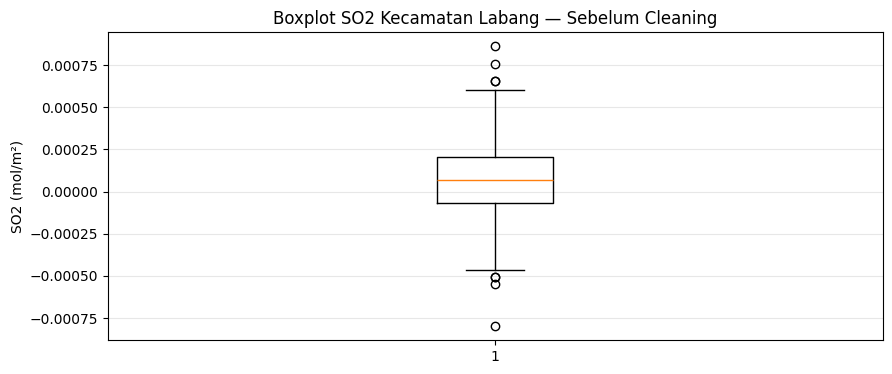

In [16]:
plt.figure(figsize=(10, 4))
plt.boxplot(dfSO2["SO2"].dropna())
plt.title("Boxplot SO2 Kecamatan Labang — Sebelum Cleaning")
plt.ylabel("SO2 (mol/m\u00b2)")
plt.grid(axis="y", alpha=0.3)
plt.show()

### 3.11 Membentuk kalender harian lengkap

Karena analisis bersifat time series harian, tanggal yang **tidak muncul sama sekali** pada data mentah (misalnya karena tidak ada lintasan satelit yang valid) juga harus dianggap sebagai *missing*, bukan hanya baris dengan nilai `NaN`. Oleh karena itu dibuat kalender penuh dari 31-08-2025 sampai 31-08-2026, lalu data di-*reindex* ke kalender tersebut — tanggal yang tidak ada datanya otomatis menjadi `NaN`.


In [17]:
full_dates = pd.date_range(start="2025-08-31", end="2026-08-31", freq="D")

df_clean = (
    dfSO2[["date", "SO2"]]
    .drop_duplicates(subset="date")
    .set_index("date")
    .reindex(full_dates)
)
df_clean.index.name = "date"

print("Jumlah tanggal seharusnya (kalender penuh) :", len(full_dates))
print("Jumlah baris setelah reindex                :", len(df_clean))
print("Jumlah missing setelah reindex               :", int(df_clean['SO2'].isna().sum()))

Jumlah tanggal seharusnya (kalender penuh) : 366
Jumlah baris setelah reindex                : 366
Jumlah missing setelah reindex               : 131


### 3.12 Imputasi missing value dan outlier

**Urutan proses:**

1. Nilai di luar batas IQR (dari poin 3.10) $\rightarrow$ ditandai `NaN`.
2. *Missing values* di **tengah** *time series* $\rightarrow$ diisi dengan **interpolasi linear berbasis waktu** (`interpolate(method="time")`).
3. *Missing values* yang tersisa di **ujung awal/akhir** (tidak bisa diinterpolasi karena tidak ada titik pembanding di salah satu sisi) $\rightarrow$ diisi dengan *forward fill* (`ffill`) lalu *backward fill* (`bfill`).
4. Validasi ulang $\rightarrow$ pastikan tidak ada `NaN` yang tersisa.

**Rumus interpolasi linear** — untuk mengisi titik kosong pada waktu $t$ yang berada di antara dua titik dikenal $(t_1, y_1)$ dan $(t_2, y_2)$:

$$y(t) = y_1 + \frac{t - t_1}{t_2 - t_1} \times (y_2 - y_1)$$

**Contoh perhitungan manual:**  
Andaikan $\text{NO}_2$ pada 10 Januari 2026 $= 3.0 \times 10^{-5}$ dan pada 12 Januari 2026 $= 5.0 \times 10^{-5}$, sedangkan 11 Januari 2026 kosong. Karena $t = 11 \text{ Jan}$ tepat di tengah $t_1 = 10 \text{ Jan}$ dan $t_2 = 12 \text{ Jan}$, maka $\frac{t - t_1}{t_2 - t_1} = \frac{1}{2}$, sehingga:

$$y(11\text{ Jan}) = 3.0 \times 10^{-5} + \frac{1}{2} \times \left(5.0 \times 10^{-5} - 3.0 \times 10^{-5}\right) = 4.0 \times 10^{-5}$$

Ini setara dengan rata-rata sederhana $\frac{y_1 + y_2}{2}$ karena titik kosong berada tepat di tengah selisih waktu satu hari. Jika jarak waktunya tidak simetris, bobot $\frac{t - t_1}{t_2 - t_1}$ akan menyesuaikan secara proporsional — inilah yang membedakan interpolasi *time-based* dari sekadar mengisi rata-rata global.


In [18]:
# Tandai outlier pada data kalender penuh sebagai NaN
clean_outlier_mask = (df_clean["SO2"] < lower_bound) | (df_clean["SO2"] > upper_bound)
n_outliers_in_full_series = int(clean_outlier_mask.sum())

df_clean.loc[clean_outlier_mask, "SO2"] = np.nan
missing_before_imputation = int(df_clean["SO2"].isna().sum())

print("Outlier yang ditandai ulang jadi NaN pada kalender penuh :", n_outliers_in_full_series)
print("Total missing sebelum imputasi (outlier + gap kalender)   :", missing_before_imputation)

# Interpolasi berbasis waktu untuk missing di tengah deret
df_clean["SO2"] = df_clean["SO2"].interpolate(method="time")

# Sisa missing di ujung awal/akhir (tidak bisa diinterpolasi) -> ffill lalu bfill
df_clean["SO2"] = df_clean["SO2"].ffill().bfill()

missing_after_imputation = int(df_clean["SO2"].isna().sum())
print("Missing setelah imputasi                                  :", missing_after_imputation)

Outlier yang ditandai ulang jadi NaN pada kalender penuh : 8
Total missing sebelum imputasi (outlier + gap kalender)   : 139
Missing setelah imputasi                                  : 0


### 3.13 Validasi sebelum ekstraksi TSFEL

Sinyal dianggap layak diproses TSFEL hanya jika **seluruh** syarat berikut terpenuhi:

- jumlah observasi = 366 (sesuai kalender penuh);
- kolom `SO2` bertipe numerik;
- tidak ada `NaN`;
- tidak ada `+inf` / `-inf`;
- tanggal terurut menaik (monotonic increasing).


In [19]:
df_final_signal = df_clean[["SO2"]].copy()

checks = {
    "Tidak ada missing value"   : df_final_signal["SO2"].isna().sum() == 0,
    "Tidak ada nilai +infinity" : np.isposinf(df_final_signal["SO2"]).sum() == 0,
    "Tidak ada nilai -infinity" : np.isneginf(df_final_signal["SO2"]).sum() == 0,
    "Kolom SO2 numerik"         : pd.api.types.is_numeric_dtype(df_final_signal["SO2"]),
    "Jumlah tanggal lengkap"    : len(df_final_signal) == len(full_dates),
    "Tanggal terurut menaik"    : df_final_signal.index.is_monotonic_increasing,
}

for name, result in checks.items():
    print(f"[{'OK' if result else 'GAGAL'}] {name}")

if all(checks.values()):
    print("\nVALIDASI LULUS -> data siap untuk ekstraksi fitur TSFEL.")
else:
    raise ValueError("VALIDASI GAGAL -> periksa kembali tahap deteksi outlier/imputasi sebelum lanjut.")

[OK] Tidak ada missing value
[OK] Tidak ada nilai +infinity
[OK] Tidak ada nilai -infinity
[OK] Kolom SO2 numerik
[OK] Jumlah tanggal lengkap
[OK] Tanggal terurut menaik

VALIDASI LULUS -> data siap untuk ekstraksi fitur TSFEL.


In [20]:
df_final_signal.reset_index().to_csv("SO2_Labang_clean.csv", index=False)

print("File hasil cleaning tersimpan: SO2_Labang_clean.csv")
display(df_final_signal.head())
display(df_final_signal.tail())

colab_files.download("SO2_Labang_clean.csv")
print("Unduhan dimulai: SO2_Labang_clean.csv (data setelah outlier & missing ditangani).")

File hasil cleaning tersimpan: SO2_Labang_clean.csv


,SO2
date,
2025-08-31,0.000429146
2025-09-01,0.000298081
2025-09-02,0.00010721
2025-09-03,-0.000200289
2025-09-04,0.000194948


,SO2
date,
2026-08-27,4.19735e-05
2026-08-28,0.000123436
2026-08-29,-1.14756e-05
2026-08-30,-9.74001e-05
2026-08-31,-9.74001e-05


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Unduhan dimulai: SO2_Labang_clean.csv (data setelah outlier & missing ditangani).


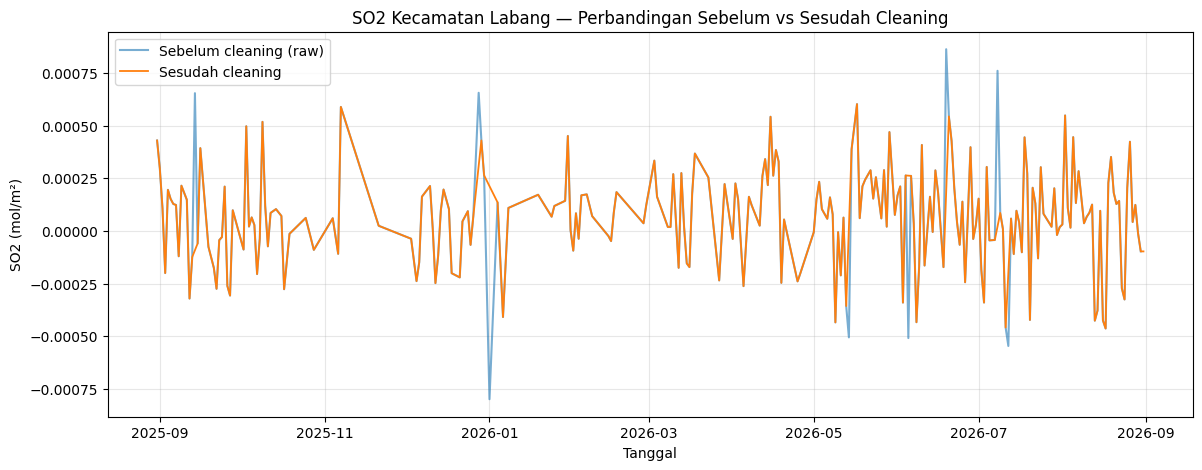

In [21]:
plt.figure(figsize=(14, 5))
plt.plot(dfSO2["date"], dfSO2["SO2"], label="Sebelum cleaning (raw)", alpha=0.6)
plt.plot(df_final_signal.index, df_final_signal["SO2"], label="Sesudah cleaning", linewidth=1.3)
plt.title("SO2 Kecamatan Labang — Perbandingan Sebelum vs Sesudah Cleaning")
plt.xlabel("Tanggal")
plt.ylabel("SO2 (mol/m\u00b2)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Modeling — Ekstraksi 68 Fitur dengan TSFEL

### 4.1 Apa itu TSFEL?

**TSFEL** (*Time Series Feature Extraction Library*) adalah pustaka Python yang menyediakan puluhan fungsi siap pakai untuk mengekstrak fitur numerik dari sebuah sinyal time series — mencakup domain **statistik**, **temporal**, **spektral (frekuensi)**, dan **fraktal/kompleksitas**. Setiap fungsi menerima array 1 dimensi (sinyal) dan mengembalikan satu (atau beberapa) nilai ringkasan.

### 4.2 Mengapa hasilnya hanya 1 baris?

**seluruh 366 nilai SO2 harian sebagai satu sinyal time series tunggal**, bukan 366 baris data independen. Oleh karena itu:

$$
\underbrace{366 \text{ nilai harian}}_{\text{1 sinyal}} \;\xrightarrow{68 \text{ fungsi TSFEL}}\; \underbrace{68 \text{ nilai ringkasan}}_{\text{1 baris} \times \text{68 kolom}}
$$

Parameter `fs` (frekuensi sampling) diset **`fs = 1`** karena satuan waktu antar-observasi adalah **1 hari**, sehingga "frekuensi" pada fitur-fitur spektral (misalnya `spectral_centroid`, `max_frequency`) diinterpretasikan dalam satuan **siklus per hari**, bukan Hz fisik biasa.



In [22]:
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat dan bersihkan data ----------
df = df_final_signal.reset_index().copy()
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_pollutant = 'SO2'

# --- FIX: paksa kolom target jadi numerik, nilai yang gagal dikonversi -> NaN ---
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

n_missing_before = df[target_pollutant].isna().sum()
print(f"Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: {n_missing_before}")

Q1 = df[target_pollutant].quantile(0.25)
Q3 = df[target_pollutant].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df.loc[(df[target_pollutant] < lower_bound) | (df[target_pollutant] > upper_bound), target_pollutant] = np.nan

df_clean = df.set_index('date').interpolate(method='time').ffill().bfill()

fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# ---------- 2. Daftar PERSIS fitur yang diminta ----------
FEATURE_LIST = '''abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross'''.split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang dihasilkan untuk {target_pollutant}: {extracted_features_final.shape[1]}")
extracted_features_final.to_csv(f'{target_pollutant}_Labang_TSFEL.csv', index=False)


Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: 0
Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang dihasilkan untuk SO2: 68


### 4.3 Validasi hasil ekstraksi

Memastikan output benar-benar berjumlah 68 kolom, nama & urutannya identik dengan `FEATURE_LIST`, serta tidak mengandung `NaN` maupun nilai tak-hingga.


In [23]:
expected_features = FEATURE_LIST

print("Shape output extracted_features_final :", extracted_features_final.shape)
print("Jumlah fitur yang diharapkan          :", len(expected_features))

same_order = list(extracted_features_final.columns) == expected_features
same_names = set(extracted_features_final.columns) == set(expected_features)

print("Nama fitur sama dengan FEATURE_LIST ? :", same_names)
print("Urutan fitur sama                    ? :", same_order)
print("Jumlah NaN pada output                :", int(extracted_features_final.isna().sum().sum()))
print("Jumlah nilai infinity pada output      :", int(np.isinf(extracted_features_final.to_numpy(dtype=float)).sum()))

if extracted_features_final.shape[1] != 68:
    raise ValueError("Output BUKAN 68 fitur -- periksa FEATURE_LIST.")
if not same_order:
    raise ValueError("Nama atau urutan fitur berubah dari FEATURE_LIST.")
if extracted_features_final.isna().any().any():
    raise ValueError("Terdapat NaN pada output fitur.")
if np.isinf(extracted_features_final.to_numpy(dtype=float)).any():
    raise ValueError("Terdapat nilai infinity pada output fitur.")

print("\nVALIDASI TSFEL LULUS -- tepat 68 fitur.")

Shape output extracted_features_final : (1, 68)
Jumlah fitur yang diharapkan          : 68
Nama fitur sama dengan FEATURE_LIST ? : True
Urutan fitur sama                    ? : True
Jumlah NaN pada output                : 0
Jumlah nilai infinity pada output      : 0

VALIDASI TSFEL LULUS -- tepat 68 fitur.


In [24]:

x = np.asarray(signal_1d, dtype=float)
n = len(x)
xbar = np.mean(x)

manual = {}

#Statistical
manual["calc_mean"] = np.sum(x) / n
manual["calc_var"] = np.sum((x - xbar)**2) / n
manual["calc_std"] = np.sqrt(manual["calc_var"])
manual["calc_max"] = np.max(x)
manual["calc_min"] = np.min(x)
manual["calc_median"] = np.median(x)

manual["mean_abs_deviation"] = np.sum(np.abs(x - xbar)) / n
manual["median_abs_deviation"] = np.median(np.abs(x - manual["calc_median"]))

q1, q3 = np.percentile(x, [25, 75])
manual["interq_range"] = q3 - q1

m2 = np.mean((x - xbar)**2)
m3 = np.mean((x - xbar)**3)
m4 = np.mean((x - xbar)**4)
manual["skewness"] = m3 / (m2**1.5) if m2 != 0 else np.nan
manual["kurtosis"] = m4 / (m2**2) - 3 if m2 != 0 else np.nan

#Temporal
manual["abs_energy"] = np.sum(x**2)
manual["rms"] = np.sqrt(np.mean(x**2))

diff = np.diff(x)
manual["mean_diff"] = np.mean(diff)
manual["mean_abs_diff"] = np.mean(np.abs(diff))
manual["median_diff"] = np.median(diff)
manual["median_abs_diff"] = np.median(np.abs(diff))
manual["sum_abs_diff"] = np.sum(np.abs(diff))
manual["pk_pk_distance"] = np.max(x) - np.min(x)

# slope terhadap indeks waktu 0..n-1
t = np.arange(n, dtype=float)
manual["slope"] = np.sum((t - t.mean()) * (x - xbar)) / np.sum((t - t.mean())**2)

# autocorrelation lag-1
if n > 1 and np.std(x[:-1]) != 0 and np.std(x[1:]) != 0:
    manual["autocorr"] = np.corrcoef(x[:-1], x[1:])[0, 1]
else:
    manual["autocorr"] = np.nan

# zero crossing pada sinyal yang sudah dipusatkan terhadap mean
centered = x - xbar
manual["zero_cross"] = np.sum(centered[:-1] * centered[1:] < 0)

X = np.fft.rfft(x)
P = np.abs(X)**2
freq = np.fft.rfftfreq(n, d=1.0)  # fs = 1 observasi/hari

manual["average_power"] = np.mean(P)
manual["max_power_spectrum"] = np.max(P)
manual["max_frequency"] = freq[np.argmax(P)]
manual["spectral_centroid"] = (
    np.sum(freq * P) / np.sum(P) if np.sum(P) != 0 else np.nan
)

# spectral spread
sc = manual["spectral_centroid"]
manual["spectral_spread"] = (
    np.sqrt(np.sum(P * (freq - sc)**2) / np.sum(P))
    if np.sum(P) != 0 else np.nan
)

# spectral entropy
p = P / np.sum(P) if np.sum(P) != 0 else np.zeros_like(P)
p_nonzero = p[p > 0]
manual["spectral_entropy"] = -np.sum(p_nonzero * np.log2(p_nonzero))

try:
    import pywt
    coeffs = pywt.wavedec(x, wavelet="db1", mode="symmetric")
    w = np.concatenate([np.asarray(c, dtype=float).ravel() for c in coeffs])
    manual["wavelet_abs_mean"] = np.mean(np.abs(w))
    manual["wavelet_energy"] = np.sum(w**2)
    manual["wavelet_std"] = np.std(w)
    manual["wavelet_var"] = np.var(w)
    energies = np.array([np.sum(np.asarray(c, dtype=float)**2) for c in coeffs])
    pe = energies / energies.sum() if energies.sum() else energies
    pe = pe[pe > 0]
    manual["wavelet_entropy"] = -np.sum(pe * np.log2(pe))
except Exception:
    print("PyWavelets tidak tersedia; fitur wavelet manual dilewati.")

print(f"Jumlah observasi yang digunakan: {n}")
print("Contoh hasil perhitungan manual:")
manual_df = pd.DataFrame(
    {"Fitur": list(manual.keys()), "Nilai manual": list(manual.values())}
)
display(manual_df)

# Bandingkan dengan output TSFEL hanya jika nama fitur tersedia.
if "extracted_features_final" in globals():
    rows = []
    for feat, val in manual.items():
        if feat in extracted_features_final.columns and np.isfinite(val):
            tsfel_val = extracted_features_final.loc[0, feat]
            rows.append({
                "Fitur": feat,
                "Manual": val,
                "TSFEL": tsfel_val,
                "Selisih_abs": abs(val - tsfel_val)
            })
    if rows:
        comparison = pd.DataFrame(rows)
        display(comparison.sort_values("Selisih_abs"))
        print(
            "Catatan: perbedaan dapat muncul jika definisi/parameter internal "
            "TSFEL berbeda dari formula ilustratif manual, terutama untuk fitur "
            "yang memiliki beberapa varian implementasi."
        )


Jumlah observasi yang digunakan: 366
Contoh hasil perhitungan manual:


,Fitur,Nilai manual
0,calc_mean,7.48214e-05
1,calc_var,2.64642e-08
2,calc_std,0.000162678
3,calc_max,0.000469114
4,calc_min,-0.000340546
5,calc_median,7.71374e-05
6,mean_abs_deviation,0.000127489
7,median_abs_deviation,9.64782e-05
8,interq_range,0.000192845
9,skewness,-0.0729682


,Fitur,Manual,TSFEL,Selisih_abs
0,calc_mean,7.48214e-05,7.48214e-05,0
1,calc_var,2.64642e-08,2.64642e-08,0
2,calc_std,0.000162678,0.000162678,0
3,calc_max,0.000469114,0.000469114,0
4,calc_min,-0.000340546,-0.000340546,0
5,calc_median,7.71374e-05,7.71374e-05,0
6,mean_abs_deviation,0.000127489,0.000127489,0
7,median_abs_deviation,9.64782e-05,9.64782e-05,0
8,interq_range,0.000192845,0.000192845,0
11,abs_energy,1.17348e-05,1.17348e-05,0


Catatan: perbedaan dapat muncul jika definisi/parameter internal TSFEL berbeda dari formula ilustratif manual, terutama untuk fitur yang memiliki beberapa varian implementasi.


### 3.9.1 Contoh perhitungan manual SO₂ dengan beberapa observasi

Bagian ini memperlihatkan cara menghitung statistik SO₂ secara manual menggunakan contoh kecil. Tujuannya agar rumus tidak hanya ditulis, tetapi juga terlihat penerapannya.

Misalkan lima observasi SO₂ adalah:

$$x = [2,\,4,\,4,\,5,\,7]$$

**1. Mean**

$$\bar{x}=\frac{2+4+4+5+7}{5}=\frac{22}{5}=4.4$$

**2. Median**

Data sudah terurut: $[2,4,4,5,7]$. Karena $n=5$ ganjil, median adalah nilai ke-3:

$$Median=4$$

**3. Variance populasi**

$$\sigma^2=\frac{(2-4.4)^2+(4-4.4)^2+(4-4.4)^2+(5-4.4)^2+(7-4.4)^2}{5}$$

$$=\frac{5.76+0.16+0.16+0.36+6.76}{5}=\frac{13.20}{5}=2.64$$

**4. Standar deviasi**

$$\sigma=\sqrt{2.64}\approx1.6248$$

**5. IQR**

Untuk lima data tersebut, $Q_1=4$ dan $Q_3=5$, sehingga:

$$IQR=Q_3-Q_1=5-4=1$$

Batas outlier:

$$Lower=4-1.5(1)=2.5$$

$$Upper=5+1.5(1)=6.5$$

Jadi nilai 2 dan 7 berada di luar batas dan diklasifikasikan sebagai outlier menurut aturan IQR.

Contoh ini **hanya ilustrasi perhitungan**. Nilai hasil analisis sebenarnya tetap dihitung dari seluruh sinyal SO₂ yang tersedia setelah proses cleaning.

In [25]:
DOMAIN_MAP = {
    "Statistical": [
        "ecdf", "ecdf_percentile", "ecdf_percentile_count", "ecdf_slope", "entropy",
        "hist_mode", "interq_range", "kurtosis", "calc_max", "calc_mean",
        "mean_abs_deviation", "calc_median", "median_abs_deviation", "calc_min",
        "skewness", "calc_std", "calc_var",
    ],
    "Temporal": [
        "abs_energy", "auc", "autocorr", "calc_centroid", "distance", "dfa",
        "higuchi_fractal_dimension", "hurst_exponent", "lempel_ziv",
        "maximum_fractal_length", "mean_abs_diff", "mean_diff", "median_abs_diff",
        "median_diff", "negative_turning", "positive_turning", "neighbourhood_peaks",
        "petrosian_fractal_dimension", "pk_pk_distance", "slope", "sum_abs_diff",
        "zero_cross", "rms", "mse",
    ],
    "Spectral": [
        "average_power", "fundamental_frequency", "human_range_energy", "lpcc", "mfcc",
        "max_power_spectrum", "max_frequency", "median_frequency", "power_bandwidth",
        "spectral_centroid", "spectral_decrease", "spectral_distance", "spectral_entropy",
        "spectral_kurtosis", "spectral_positive_turning", "spectral_roll_off",
        "spectral_roll_on", "spectral_skewness", "spectral_slope", "spectral_spread",
        "spectral_variation", "spectrogram_mean_coeff", "wavelet_abs_mean",
        "wavelet_energy", "wavelet_entropy", "wavelet_std", "wavelet_var",
    ],
}

# Validasi: setiap fitur pada FEATURE_LIST harus masuk tepat 1 domain, dan totalnya 68
all_mapped = [f for feats in DOMAIN_MAP.values() for f in feats]

missing_from_map = [f for f in FEATURE_LIST if f not in all_mapped]
extra_in_map = [f for f in all_mapped if f not in FEATURE_LIST]
duplicated_in_map = [f for f in set(all_mapped) if all_mapped.count(f) > 1]

print("Jumlah fitur per domain:")
for domain, feats in DOMAIN_MAP.items():
    print(f"  {domain:<12}: {len(feats)} fitur")
print(f"  {'TOTAL':<12}: {len(all_mapped)} fitur (harus = 68)")

print("\nFitur FEATURE_LIST yang belum terpetakan ke domain mana pun:", missing_from_map)
print("Fitur pada peta domain yang TIDAK ada di FEATURE_LIST          :", extra_in_map)
print("Fitur yang tidak sengaja terdaftar di lebih dari satu domain   :", duplicated_in_map)

if not missing_from_map and not extra_in_map and not duplicated_in_map and len(all_mapped) == 68:
    print("\nPemetaan domain valid: seluruh 68 fitur terklasifikasi tepat satu kali.")
else:
    raise ValueError("Pemetaan domain tidak konsisten dengan FEATURE_LIST -- periksa DOMAIN_MAP.")

# Tampilkan nilai hasil ekstraksi, dikelompokkan per domain
for domain, feats in DOMAIN_MAP.items():
    print(f"\n=== Domain {domain} ({len(feats)} fitur) ===")
    display(extracted_features_final[feats].T.rename(columns={0: "nilai"}))

Jumlah fitur per domain:
  Statistical : 17 fitur
  Temporal    : 24 fitur
  Spectral    : 27 fitur
  TOTAL       : 68 fitur (harus = 68)

Fitur FEATURE_LIST yang belum terpetakan ke domain mana pun: []
Fitur pada peta domain yang TIDAK ada di FEATURE_LIST          : []
Fitur yang tidak sengaja terdaftar di lebih dari satu domain   : []

Pemetaan domain valid: seluruh 68 fitur terklasifikasi tepat satu kali.

=== Domain Statistical (17 fitur) ===


,nilai
ecdf,0.0150273
ecdf_percentile,7.54987e-05
ecdf_percentile_count,182.5
ecdf_slope,2621.07
entropy,0.999358
hist_mode,2.38009e-05
interq_range,0.000192845
kurtosis,-0.0585455
calc_max,0.000469114
calc_mean,7.48214e-05



=== Domain Temporal (24 fitur) ===


,nilai
abs_energy,1.17348e-05
auc,0.0456028
autocorr,2
calc_centroid,195.004
distance,365
dfa,0.843733
higuchi_fractal_dimension,1.92704
hurst_exponent,0.747389
lempel_ziv,0.191257
maximum_fractal_length,-1.27491



=== Domain Spectral (27 fitur) ===


,nilai
average_power,3.21503e-08
fundamental_frequency,0.00273224
human_range_energy,0
lpcc,0.209401
mfcc,32.469
max_power_spectrum,16.7314
max_frequency,0.459016
median_frequency,0.169399
power_bandwidth,0.387978
spectral_centroid,0.194387


### 4.4.1 Interpretasi hasil fitur untuk SO₂

Setelah seluruh observasi harian SO₂ dibersihkan, 366 nilai diperlakukan sebagai **satu sinyal time series**. Oleh karena itu 68 fitur bukan berarti 68 hari atau 68 sampel, melainkan 68 ringkasan numerik yang menggambarkan karakteristik SO₂ selama periode pengamatan.

Contoh interpretasi:

- `calc_mean` → rata-rata SO₂ selama periode analisis.
- `calc_max` dan `calc_min` → nilai SO₂ tertinggi dan terendah.
- `calc_std` dan `calc_var` → tingkat penyebaran/variabilitas SO₂.
- `skewness` → apakah distribusi SO₂ cenderung memiliki ekor ke kanan atau kiri.
- `kurtosis` → tingkat keruncingan/ekstremitas distribusi.
- `slope` → kecenderungan SO₂ meningkat atau menurun sepanjang waktu.
- `autocorr` → keterkaitan nilai SO₂ dengan nilai pada hari sebelumnya.
- `abs_energy` dan `rms` → ukuran kekuatan/amplitudo sinyal.
- fitur spektral → karakteristik pola periodik/frekuensi dalam deret waktu SO₂.
- fitur wavelet → karakteristik SO₂ pada beberapa skala waktu.


In [26]:
x = signal_1d.astype(float)
n = len(x)
xbar = x.mean()

# calc_mean
manual_mean = sum(x) / n

# calc_var, calc_std
manual_var = sum((v - manual_mean) ** 2 for v in x) / n
manual_std = np.sqrt(manual_var)

# abs_energy, rms
manual_abs_energy = sum(v * v for v in x)
manual_rms = np.sqrt(manual_abs_energy / n)

# mean_abs_diff, median_abs_diff
diffs_abs = [abs(x[i] - x[i - 1]) for i in range(1, n)]
manual_mean_abs_diff = sum(diffs_abs) / len(diffs_abs)
diffs_abs_sorted = sorted(diffs_abs)
m = len(diffs_abs_sorted)
manual_median_abs_diff = (diffs_abs_sorted[m // 2] if m % 2 == 1
                           else (diffs_abs_sorted[m // 2 - 1] + diffs_abs_sorted[m // 2]) / 2)

# pk_pk_distance
manual_pk_pk = x.max() - x.min()

# zero_cross
centered = x - manual_mean
manual_zero_cross = sum(1 for i in range(1, n) if centered[i - 1] * centered[i] < 0)

# skewness & kurtosis (populasi)
m2 = sum((v - manual_mean) ** 2 for v in x) / n
m3 = sum((v - manual_mean) ** 3 for v in x) / n
m4 = sum((v - manual_mean) ** 4 for v in x) / n
manual_skewness = m3 / (m2 ** 1.5)
manual_kurtosis = m4 / (m2 ** 2) - 3.0

#slope: regresi linear terhadap indeks waktu t = 0..n-1
t = np.arange(n)
t_bar = t.mean()
num = sum((t[i] - t_bar) * (x[i] - manual_mean) for i in range(n))
den = sum((t[i] - t_bar) ** 2 for i in range(n))
manual_slope = num / den

# autocorr lag-1 (korelasi Pearson x[i] vs x[i-1])
x1 = x[:-1]
x2 = x[1:]
x1bar, x2bar = x1.mean(), x2.mean()
cov12 = sum((x1[i] - x1bar) * (x2[i] - x2bar) for i in range(len(x1)))
std1 = np.sqrt(sum((v - x1bar) ** 2 for v in x1))
std2 = np.sqrt(sum((v - x2bar) ** 2 for v in x2))
manual_autocorr = cov12 / (std1 * std2)

manual_results = {
    "calc_mean": manual_mean,
    "calc_var": manual_var,
    "calc_std": manual_std,
    "abs_energy": manual_abs_energy,
    "rms": manual_rms,
    "mean_abs_diff": manual_mean_abs_diff,
    "median_abs_diff": manual_median_abs_diff,
    "pk_pk_distance": manual_pk_pk,
    "zero_cross": manual_zero_cross,
    "skewness": manual_skewness,
    "kurtosis": manual_kurtosis,
    "slope": manual_slope,
    "autocorr": manual_autocorr,
}

print(f"{'Fitur':<18}{'Manual':>18}{'TSFEL':>18}{'Selisih absolut':>20}")
print("-" * 74)
for feat, manual_val in manual_results.items():
    tsfel_val = extracted_features_final.loc[0, feat]
    selisih = abs(manual_val - tsfel_val)
    print(f"{feat:<18}{manual_val:>18.6g}{tsfel_val:>18.6g}{selisih:>20.3g}")

print("\nCatatan: selisih yang sangat kecil (mendekati 0, misal < 1e-6) menandakan")
print("rumus manual konsisten dengan implementasi internal TSFEL. Jika ada selisih")
print("relatif lebih besar, hal ini umumnya disebabkan perbedaan pembagi (populasi vs")
print("sampel) atau definisi turunan (mis. excess vs non-excess kurtosis) pada versi TSFEL yang dipakai.")

Fitur                         Manual             TSFEL     Selisih absolut
--------------------------------------------------------------------------
calc_mean                7.48214e-05       7.48214e-05                   0
calc_var                 2.64642e-08       2.64642e-08            6.62e-24
calc_std                 0.000162678       0.000162678            2.71e-20
abs_energy               1.17348e-05       1.17348e-05            1.69e-21
rms                       0.00017906        0.00017906                   0
mean_abs_diff            0.000114619       0.000114619            1.36e-20
median_abs_diff          5.87521e-05       5.87521e-05                   0
pk_pk_distance            0.00080966        0.00080966                   0
zero_cross                       101                87                  14
skewness                  -0.0729682        -0.0729682            6.94e-17
kurtosis                  -0.0585455        -0.0585455            1.33e-15
slope                    

## 5. Evaluation

### 5.1 Kualitas data time series
- periode lengkap 366 hari (31-08-2025 s.d. 31-08-2026);
- tanggal terurut menaik;
- kolom `SO2` numerik;
- missing value setelah imputasi = 0;
- nilai infinity = 0.

### 5.2 Penanganan outlier
- $Q_1$, $Q_3$, dan $\text{IQR}$ terdokumentasi secara eksplisit;
- Batas bawah & batas atas terdokumentasi;
- Jumlah *outlier* yang terdeteksi tercatat;
- Seluruh *outlier* ditangani (diimputasi) sebelum ekstraksi fitur.

> **Catatan konseptual:** outlier secara statistik tidak selalu berarti kesalahan pengukuran — bisa jadi representasi peristiwa nyata (misalnya lonjakan aktivitas kendaraan).

### 5.3 Output TSFEL
- tepat 68 fitur;
- nama dan urutan kolom identik dengan `FEATURE_LIST`;
- tidak ada `NaN`;
- tidak ada nilai infinity.


In [27]:
evaluation = pd.DataFrame({
    "Metrik": [
        "Periode mulai",
        "Periode akhir",
        "Jumlah hari (kalender penuh)",
        "Q1 (kuartil 25%)",
        "Q3 (kuartil 75%)",
        "IQR",
        "Batas bawah outlier",
        "Batas atas outlier",
        "Jumlah outlier terdeteksi",
        "Missing sebelum imputasi",
        "Missing sesudah imputasi",
        "Jumlah fitur TSFEL dihasilkan",
        "NaN pada output TSFEL",
        "Infinity pada output TSFEL",
    ],
    "Hasil": [
        str(full_dates.min().date()),
        str(full_dates.max().date()),
        len(full_dates),
        round(float(q1), 6),
        round(float(q3), 6),
        round(float(iqr), 6),
        round(float(lower_bound), 6),
        round(float(upper_bound), 6),
        n_outliers_in_full_series,
        missing_before_imputation,
        missing_after_imputation,
        extracted_features_final.shape[1],
        int(extracted_features_final.isna().sum().sum()),
        int(np.isinf(extracted_features_final.to_numpy(dtype=float)).sum()),
    ]
})

display(evaluation)

evaluation_passed = (
    len(full_dates) == 366 and
    missing_after_imputation == 0 and
    extracted_features_final.shape[1] == 68 and
    extracted_features_final.isna().sum().sum() == 0 and
    np.isinf(extracted_features_final.to_numpy(dtype=float)).sum() == 0
)

print("\nEVALUASI AKHIR:", "LULUS -- siap ke tahap Deployment" if evaluation_passed else "PERIKSA KEMBALI")

,Metrik,Hasil
0,Periode mulai,2025-08-31
1,Periode akhir,2026-08-31
2,Jumlah hari (kalender penuh),366
3,Q1 (kuartil 25%),-2.1e-05
4,Q3 (kuartil 75%),0.000172
5,IQR,0.00027
6,Batas bawah outlier,-0.000347
7,Batas atas outlier,0.000494
8,Jumlah outlier terdeteksi,8
9,Missing sebelum imputasi,139



EVALUASI AKHIR: LULUS -- siap ke tahap Deployment


## 6. Deployment

### 6.1 File final: `SO2_Labang_TSFEL.csv`

File ini adalah **satu-satunya** file yang dikumpulkan sebagai hasil ekstraksi fitur.


In [28]:
FINAL_CSV = "SO2_Labang_TSFEL.csv"

check_csv = pd.read_csv(FINAL_CSV)

print("File          :", FINAL_CSV)
print("Shape         :", check_csv.shape)
print("Kolom pertama :", check_csv.columns[0])
print("Kolom terakhir:", check_csv.columns[-1])

if check_csv.shape != (1, 68):
    raise ValueError(f"Shape salah: {check_csv.shape}; seharusnya (1, 68). Periksa kembali Bagian 4.")

print("\nFile final tervalidasi: 1 baris x 68 kolom, siap dikumpulkan.")

File          : SO2_Labang_TSFEL.csv
Shape         : (1, 68)
Kolom pertama : abs_energy
Kolom terakhir: zero_cross

File final tervalidasi: 1 baris x 68 kolom, siap dikumpulkan.


In [29]:
colab_files.download(FINAL_CSV)
print("Unduhan dimulai:", FINAL_CSV, "-- JANGAN diubah/di-edit setelah ini.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Unduhan dimulai: SO2_Labang_TSFEL.csv -- JANGAN diubah/di-edit setelah ini.
